# Exec/Idle 耗时分布

数据来自 `exec_stats.csv`（client 退出时在运行目录导出，每 worker 的原始样本 `wid,idx,exec_us,idle_us`）。

下面把绘图逻辑封装成 `plot()` 函数，直接调用即可：idle / exec、只看某 worker、保存 png、将来 csv 加 `node_id` 列后可画 worker×节点 分面。

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def plot(csv, metric="idle", png=None, wid=None, by_node=False, q=0.99):
    """读 exec_stats.csv 画每 worker 的 exec/idle 耗时分布（violin + range line + P99/mean/min 标注）。

    参数
    ----
    csv      : 路径。列应为 wid,idx,exec_us,idle_us；若含 node_id 列 + by_node=True
               则按 worker×节点 分面（每 worker 一子图，x=节点）。
    metric   : 画哪列，"idle"（默认）或 "exec"。
    png      : 不 None → 保存到该路径（并关闭显示）；Jupyter 里不传 → 内联显示。
    wid      : 只画该 worker（int，None=全部）。
    by_node  : 有 node_id 列时按节点分组（仅 exec 有意义，idle 是 worker 级空档）。
    q        : 分布截断分位（默认 0.99，砍掉离群尾巴避免把坐标轴拉爆）。

    返回
    ----
    fig      : 可直接继续修饰；Jupyter 里直接 plot(...) 即显示。
    """
    df = pd.read_csv(csv)
    if wid is not None:
        df = df[df["wid"] == wid]
    has_node = "node_id" in df.columns
    col = {"exec": "exec_us", "idle": "idle_us"}[metric]

    cols = ["wid", col]
    if has_node and by_node:
        cols.append("node_id")
    d = df[cols].rename(columns={col: "us"})
    d = d[d["us"] > 0]
    if d.empty:
        print(f"[plot] {csv}: no positive {metric} samples")
        return None

    cap = d["us"].quantile(q)
    d_cut = d[d["us"] <= cap]

    sns.set_theme(style="whitegrid")

    if has_node and by_node:
        # worker × 节点：每 worker 一子图，x=节点，看 exec 分布差异
        g = sns.FacetGrid(d_cut, col="wid", height=4)
        g.map_dataframe(sns.violinplot, x="node_id", y="us", cut=0, inner="box")
        g.set_axis_labels("node id", f"{metric} time (us)")
        g.fig.subplots_adjust(top=0.88)
        g.fig.suptitle(f"per-worker × per-node {metric} (P{q:.0%} cap)")
        fig = g.fig
    else:
        fig, ax = plt.subplots(figsize=(9, 6))
        sns.violinplot(data=d_cut, x="wid", y="us", hue="wid", legend=False,
                       palette="Set2", cut=0, inner=None, linewidth=0, ax=ax)
        ax.set_ylabel(f"{metric} time (us)")
        ax.set_title(f"per-worker {metric} distribution (P{q:.0%}, linear)")
        n_wid = len(d["wid"].unique())
        ax.set_xlim(-0.4, n_wid - 0.6)
        # range line（min→P99 竖线）+ P99/mean/min 短刻度与对齐标注
        for xpos, w in enumerate(d["wid"].unique()):
            sub = d.loc[d["wid"] == w, "us"]
            mn, mean, p99 = sub.min(), sub.mean(), sub.quantile(0.99)
            vx = xpos
            ax.plot([vx, vx], [mn, p99], color="0.35", lw=1.0)
            for val in (p99, mean, mn):
                ax.plot([vx - 0.02, vx + 0.02], [val, val], color="0.35", lw=1.2)
                ax.text(vx + 0.09, val, f"{val:.1f}", ha="left", va="center",
                        fontsize=8, family="monospace")
        ax.set_ylim(0, cap * 1.15)

    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150)
        print("saved:", png)
        plt.close(fig)
    return fig

In [8]:
def plot_main_loop(path, png=None):
    """画 main_loop_stats.csv（kind,idx,us,extra）。
    左：rollover 耗时随 idx 的时序散点；右：rollover 直方图 + min/mean/p50/p99/max 标注。
    标题标注 expand 单次耗时（若有）。
    """
    df = pd.read_csv(path)
    if df.empty:
        print(f"[plot_main_loop] {path}: empty")
        return None
    r = df[df["kind"] == "rollover"]
    e = df[df["kind"] == "expand"]
    if r.empty:
        print(f"[plot_main_loop] {path}: no rollover samples")
        return None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.scatter(r["idx"], r["us"], s=4, alpha=0.15, color="steelblue", linewidth=0)
    ax1.set_xlabel("idx")
    ax1.set_ylabel("rollover time (us)")
    ax1.set_title(f"rollover time over idx (n={len(r)})")

    us = r["us"]
    ax2.hist(us, bins=60, color="steelblue", alpha=0.7)
    ax2.set_xlabel("rollover time (us)")
    ax2.set_ylabel("count")
    top = ax2.get_ylim()[1]
    for lab, val in (("min", us.min()), ("mean", us.mean()),
                     ("p50", us.quantile(0.50)), ("p99", us.quantile(0.99)), ("max", us.max())):
        ax2.axvline(val, color="crimson" if lab in ("p99", "max") else "0.4",
                    lw=1, ls="--")
        ax2.text(val, top * 0.97, f" {lab}={val:.2f}", rotation=90, va="top",
                 ha="center", fontsize=8, family="monospace")
    ax2.set_title("rollover time distribution")
    if not e.empty:
        fig.suptitle(f"main loop events | expand n={len(e)} us={e['us'].iloc[0]:.2f} (idx={e['idx'].iloc[0]})")
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150, bbox_inches="tight")
        print("saved:", png)
        plt.close(fig)
    return fig


def plot_wid_idle_latency(path, png=None, q=0.99, wid=None, metric="idle"):
    """画 per-worker 耗时分布（violin + range line + P99/mean/min 标注）。
    内部复用 plot() 的分布逻辑；metric="idle"（默认）或 "exec"。
    """
    return plot(path, metric=metric, png=png, q=q, wid=wid)


def plot_algo_wrap_latency(path, png=None, q=0.99, algo=None):
    """画 algo_exec_stats.csv（algo,idx,diff_us）：per-algo 执行耗时分布。
    风格与 plot() 一致：violin + min→P99 range line + P99/mean/min 标注。
    algo=None 画全部，或传 "usr_src"/"usr_sink"/"usr_join10" 只看单个。
    """
    df = pd.read_csv(path)
    if algo is not None:
        df = df[df["algo"] == algo]
    d = df[["algo", "diff_us"]].rename(columns={"diff_us": "us"})
    d = d[d["us"] > 0]
    if d.empty:
        print(f"[plot_algo_exec] {path}: no positive diff_us samples")
        return None
    cap = d["us"].quantile(q)
    d_cut = d[d["us"] <= cap]
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.violinplot(data=d_cut, x="algo", y="us", hue="algo", legend=False,
                   palette="Set2", cut=0, inner=None, linewidth=0, ax=ax)
    ax.set_ylabel("algo exec time (us)")
    ax.set_title(f"per-algo exec time distribution (P{q:.0%}, linear)")
    n_algo = len(d["algo"].unique())
    ax.set_xlim(-0.4, n_algo - 0.6)
    for xpos, a in enumerate(d["algo"].unique()):
        sub = d.loc[d["algo"] == a, "us"]
        mn, mean, p99 = sub.min(), sub.mean(), sub.quantile(0.99)
        ax.plot([xpos, xpos], [mn, p99], color="0.35", lw=1.0)
        for val in (p99, mean, mn):
            ax.plot([xpos - 0.02, xpos + 0.02], [val, val], color="0.35", lw=1.2)
            ax.text(xpos + 0.06, val, f"{val:.1f}", ha="left", va="center",
                    fontsize=8, family="monospace")
    ax.set_ylim(0, cap * 1.15)
    fig.tight_layout()
    if png:
        fig.savefig(png, dpi=150)
        print("saved:", png)
        plt.close(fig)
    return fig

In [9]:
# ---- 四份 CSV 各画一张（路径按需改）----
base = "."

saved: exec_stats_idle.png


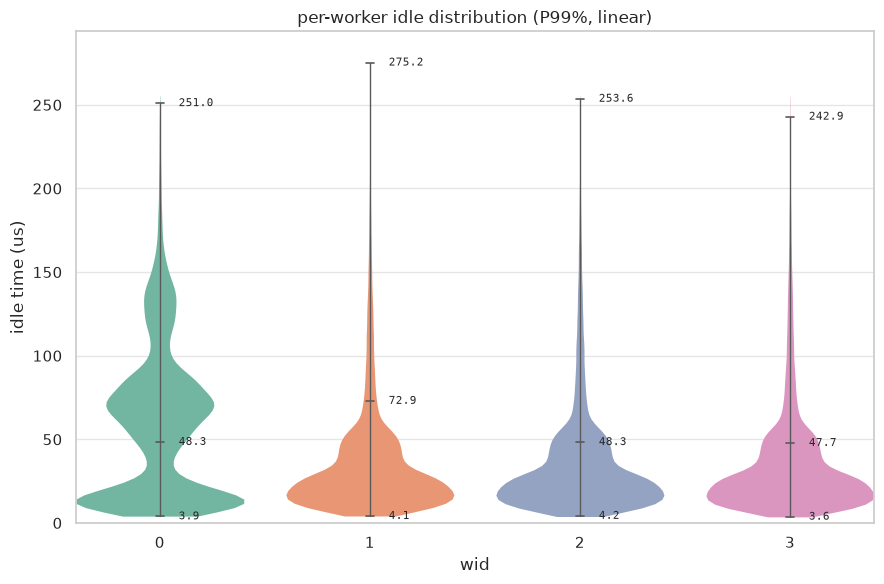

In [10]:
plot_wid_idle_latency(f"{base}/wid_exec_stats.csv", metric="idle", png="exec_stats_idle.png")

saved: main_loop_stats.png


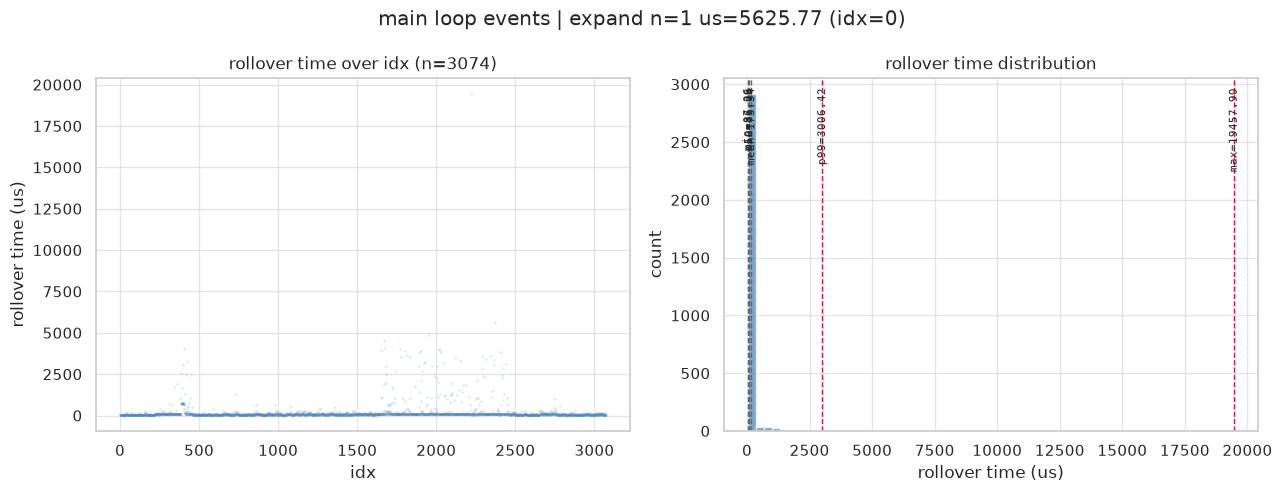

In [11]:
plot_main_loop(f"{base}/main_loop_stats.csv", png="main_loop_stats.png")

saved: algo_exec_stats.png


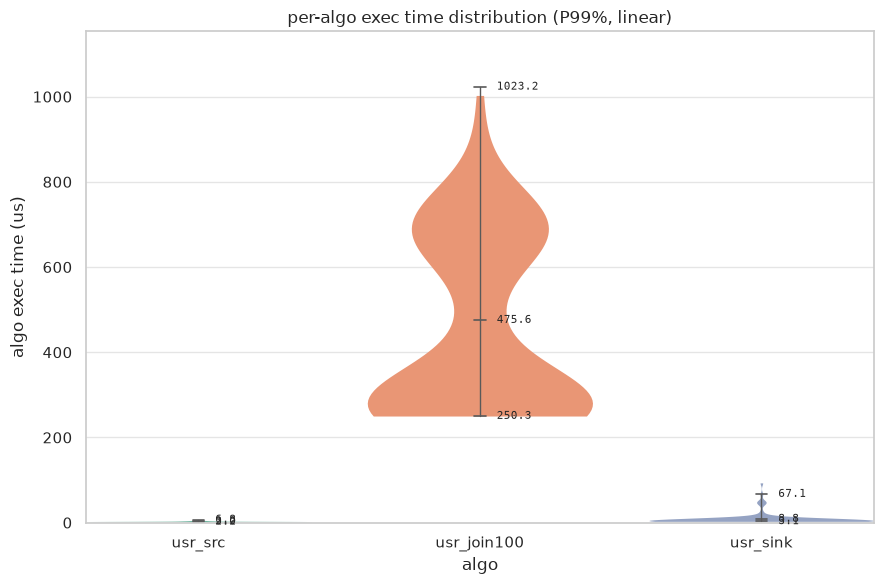

In [12]:
plot_algo_wrap_latency(f"{base}/algo_exec_stats.csv", png="algo_exec_stats.png")